# 🤖 BƯỚC 5: Sentiment Analysis
## Phần A — Traditional Machine Learning

---
### 🎯 Mục tiêu:
Train và so sánh **4 model Traditional ML** để phân loại sentiment:
- `0` = negative | `1` = neutral | `2` = positive

### 📋 Model sẽ train:
```
1. Logistic Regression  → baseline chuẩn
2. SGD Classifier       → phù hợp data lớn
3. Linear SVM           → thường tốt nhất với text
4. Random Forest        → ensemble, ít overfit
```

### 📁 File cần có trên Drive:
```
outputs/models/review_features_train.npz
outputs/models/review_features_test.npz
outputs/models/review_labels_train.npy
outputs/models/review_labels_test.npy
```

## Cell 0 — Mount Drive & Cài thư viện

In [1]:
# ============================================================
# CELL 0: Mount Google Drive và cài thư viện
#
# matplotlib: vẽ biểu đồ confusion matrix và learning curve
# joblib    : lưu model sklearn nhanh hơn pickle
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn matplotlib joblib -q

print('✅ Ready!')

Mounted at /content/drive
✅ Ready!


## Cell 1 — Import & Setup đường dẫn

In [2]:
# ============================================================
# CELL 1: Import thư viện và khai báo đường dẫn
#
# scipy.sparse : đọc file .npz (sparse matrix)
# joblib       : lưu/load model sklearn
# time         : đo thời gian train từng model
# ============================================================

import numpy as np
import json
import time
import joblib
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from pathlib import Path
from scipy import sparse

# Traditional ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Đường dẫn
DRIVE_ROOT  = Path('/content/drive/MyDrive/amazon_clothing')
MODELS_DIR  = DRIVE_ROOT / 'outputs' / 'models'
FIGURES_DIR = DRIVE_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Label names để hiển thị
LABEL_NAMES = ['negative', 'neutral', 'positive']

print(' Import xong!')
print(f'   Models dir : {MODELS_DIR}')
print(f'   Figures dir: {FIGURES_DIR}')

 Import xong!
   Models dir : /content/drive/MyDrive/amazon_clothing/outputs/models
   Figures dir: /content/drive/MyDrive/amazon_clothing/outputs/figures


## Cell 2 — Load Feature Matrix từ Bước 4

In [3]:
# ============================================================
# CELL 2: Load dữ liệu đã chuẩn bị từ Bước 4
#
# X_train: sparse matrix (2.4M × 262144)
#   → Mỗi dòng = 1 review đã được HashingVectorizer transform
#   → Mỗi cột = 1 feature (hash của từ/bigram)
#
# y_train: array nhãn sentiment
#   → 0=negative, 1=neutral, 2=positive
#
# Tại sao dùng sparse matrix?
#   → 2.4M × 262144 = 628 tỷ ô
#   → Nhưng phần lớn = 0 (review chỉ dùng vài trăm từ)
#   → Sparse chỉ lưu ô khác 0 → tiết kiệm RAM
# ============================================================

print('📦 Loading feature matrices từ Bước 4...')

X_train = sparse.load_npz(str(MODELS_DIR / 'review_features_train.npz'))
X_test  = sparse.load_npz(str(MODELS_DIR / 'review_features_test.npz'))
y_train = np.load(str(MODELS_DIR / 'review_labels_train.npy'))
y_test  = np.load(str(MODELS_DIR / 'review_labels_test.npy'))

print(f'✅ Loaded!')
print(f'\n   X_train shape: {X_train.shape}')
print(f'   X_test  shape: {X_test.shape}')
print(f'   y_train shape: {y_train.shape}')
print(f'   y_test  shape: {y_test.shape}')

print(f'\n📊 Phân bố nhãn train:')
for i, name in enumerate(LABEL_NAMES):
    cnt = (y_train == i).sum()
    print(f'   {name:10}: {cnt:>8,} ({cnt/len(y_train)*100:.1f}%)')

print(f'\n📊 Phân bố nhãn test:')
for i, name in enumerate(LABEL_NAMES):
    cnt = (y_test == i).sum()
    print(f'   {name:10}: {cnt:>8,} ({cnt/len(y_test)*100:.1f}%)')

📦 Loading feature matrices từ Bước 4...
✅ Loaded!

   X_train shape: (2488797, 262144)
   X_test  shape: (630290, 262144)
   y_train shape: (2488797,)
   y_test  shape: (630290,)

📊 Phân bố nhãn train:
   negative  :  345,882 (13.9%)
   neutral   :  210,728 (8.5%)
   positive  : 1,932,187 (77.6%)

📊 Phân bố nhãn test:
   negative  :  109,971 (17.4%)
   neutral   :   57,060 (9.1%)
   positive  :  463,259 (73.5%)


## Cell 3 — Hàm Train & Evaluate

In [4]:
# ============================================================
# CELL 3: Định nghĩa hàm train và evaluate tái sử dụng
# ============================================================

import threading
import time

all_results = {}

def _print_timer(stop_event, model_name):
    """Thread in thời gian mỗi 30 giây"""
    t0 = time.time()
    while not stop_event.is_set():
        time.sleep(30)
        if stop_event.is_set():
            break
        elapsed = time.time() - t0
        mins    = int(elapsed // 60)
        secs    = int(elapsed % 60)
        print(f'   ⏱️  [{model_name}] Đang train: {mins:02d}:{secs:02d}...', flush=True)

def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test):

    print(f'\n{"="*55}')
    print(f'🤖 Model: {model_name}')
    print(f'{"="*55}')

    # ── TRAIN ──────────────────────────────────────────────
    print(f'🔄 Training... (sẽ báo mỗi 30 giây)')

    stop_event   = threading.Event()
    timer_thread = threading.Thread(
        target=_print_timer,
        args=(stop_event, model_name),
        daemon=True
    )
    timer_thread.start()

    t0         = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    stop_event.set()
    timer_thread.join()

    mins = int(train_time // 60)
    secs = int(train_time % 60)
    print(f'   ✅ Train xong! {mins:02d}:{secs:02d} ({train_time:.1f}s)')

    # ── PREDICT ────────────────────────────────────────────
    print(f'🔍 Predicting...')
    t1        = time.time()
    y_pred    = model.predict(X_test)
    pred_time = time.time() - t1
    print(f'   ✅ Predict xong! {pred_time:.1f}s')

    # ── METRICS ────────────────────────────────────────────
    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    print(f'\n📊 Kết quả:')
    print(f'   F1 Macro   : {f1_macro:.4f}')
    print(f'   F1 Weighted: {f1_weighted:.4f}')
    print(f'\n   F1 từng class:')
    for name, f1 in zip(LABEL_NAMES, f1_per_class):
        bar = '█' * int(f1 * 20)
        print(f'   {name:10}: {bar:<20} {f1:.4f}')

    print(f'\n   Classification Report:')
    print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

    # ── CONFUSION MATRIX ───────────────────────────────────
    cm   = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=LABEL_NAMES)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    save_path = FIGURES_DIR / f'step5_cm_{model_name.replace(" ","_").lower()}.png'
    plt.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

    # ── LƯU KẾT QUẢ ────────────────────────────────────────
    result = {
        'model'         : model_name,
        'train_time_s'  : round(train_time, 1),
        'train_time_fmt': f'{mins:02d}:{secs:02d}',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
    }
    all_results[model_name] = result

    model_path = MODELS_DIR / f'sentiment_{model_name.replace(" ","_").lower()}.joblib'
    joblib.dump(model, model_path)
    print(f'✅ Saved: {model_path.name}')

    return result

print(' Hàm train_and_evaluate sẵn sàng!')


 Hàm train_and_evaluate sẵn sàng!


## Cell 4 — Model 1: Logistic Regression


🤖 Model: Logistic Regression
🔄 Training... (sẽ báo mỗi 30 giây)
   ⏱️  [Logistic Regression] Đang train: 00:30...
   ⏱️  [Logistic Regression] Đang train: 01:00...
   ⏱️  [Logistic Regression] Đang train: 01:30...
   ⏱️  [Logistic Regression] Đang train: 02:00...
   ⏱️  [Logistic Regression] Đang train: 02:30...
   ⏱️  [Logistic Regression] Đang train: 03:00...
   ⏱️  [Logistic Regression] Đang train: 03:30...
   ⏱️  [Logistic Regression] Đang train: 04:00...
   ⏱️  [Logistic Regression] Đang train: 04:30...
   ⏱️  [Logistic Regression] Đang train: 05:00...
   ⏱️  [Logistic Regression] Đang train: 05:30...
   ⏱️  [Logistic Regression] Đang train: 06:00...
   ⏱️  [Logistic Regression] Đang train: 06:30...
   ⏱️  [Logistic Regression] Đang train: 07:00...
   ⏱️  [Logistic Regression] Đang train: 07:30...
   ⏱️  [Logistic Regression] Đang train: 08:00...
   ⏱️  [Logistic Regression] Đang train: 08:30...
   ⏱️  [Logistic Regression] Đang train: 09:00...
   ⏱️  [Logistic Regression] Đang t

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


   ✅ Train xong! 13:49 (829.8s)
🔍 Predicting...
   ✅ Predict xong! 0.2s

📊 Kết quả:
   F1 Macro   : 0.5472
   F1 Weighted: 0.7008

   F1 từng class:
   negative  : ███████████          0.5673
   neutral   : █████                0.2913
   positive  : ███████████████      0.7830

   Classification Report:
              precision    recall  f1-score   support

    negative       0.71      0.47      0.57    109971
     neutral       0.18      0.78      0.29     57060
    positive       0.98      0.65      0.78    463259

    accuracy                           0.63    630290
   macro avg       0.62      0.64      0.55    630290
weighted avg       0.86      0.63      0.70    630290



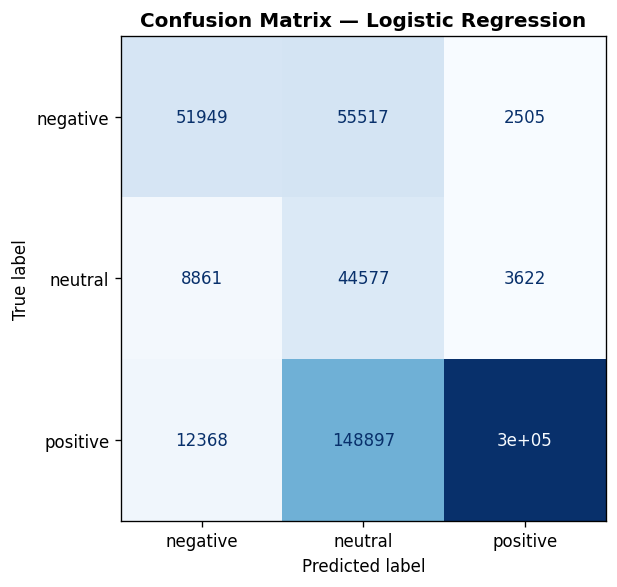

✅ Saved: sentiment_logistic_regression.joblib


In [ ]:
# ============================================================
# CELL 4: Logistic Regression
#
# Đây là BASELINE chuẩn cho bài toán classification.
# Ý tưởng: Tìm đường ranh giới tuyến tính phân chia các class
#
# Tham số quan trọng:
# → C=1.0           : regularization strength
#                     C nhỏ → model đơn giản hơn, tránh overfit
#                     C lớn → model phức tạp hơn, fit data sát hơn
# → max_iter=1000   : số vòng lặp tối đa để hội tụ
# → class_weight='balanced': tự động tăng trọng số cho class ít
#                     negative và neutral sẽ được chú ý hơn
# → solver='saga'   : thuật toán tối ưu, phù hợp data lớn
# → n_jobs=-1       : dùng tất cả CPU core
# ============================================================

lr_model = LogisticRegression(
    C            = 1.0,
    max_iter     = 100,
    class_weight = 'balanced',
    solver       = 'saga',
    random_state = 42,
    n_jobs       = -1,
    verbose      = 0
)

lr_result = train_and_evaluate(
    lr_model, 'Logistic Regression',
    X_train, y_train, X_test, y_test
)

## Cell 5 — Model 2: SGD Classifier


🤖 Model: SGD Classifier
🔄 Training... (sẽ báo mỗi 30 giây)
   ✅ Train xong! 00:23 (23.0s)
🔍 Predicting...
   ✅ Predict xong! 0.4s

📊 Kết quả:
   F1 Macro   : 0.6387
   F1 Weighted: 0.8201

   F1 từng class:
   negative  : █████████████        0.6989
   neutral   : ██████               0.3047
   positive  : ██████████████████   0.9124

   Classification Report:
              precision    recall  f1-score   support

    negative       0.66      0.74      0.70    109971
     neutral       0.32      0.29      0.30     57060
    positive       0.92      0.90      0.91    463259

    accuracy                           0.82    630290
   macro avg       0.63      0.65      0.64    630290
weighted avg       0.82      0.82      0.82    630290



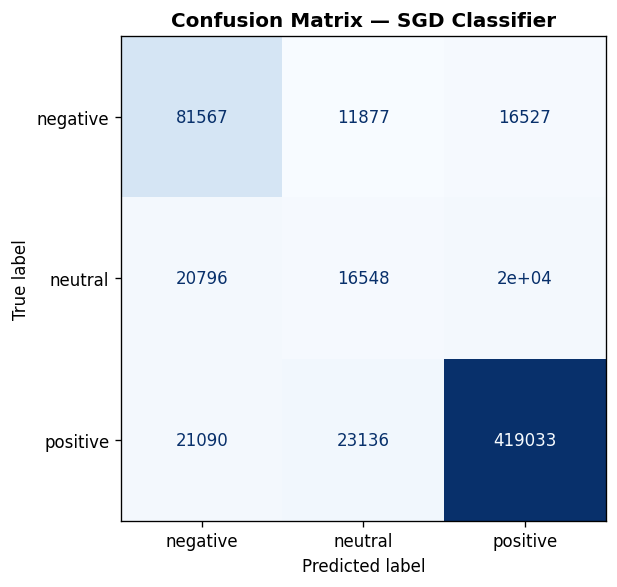

✅ Saved: sentiment_sgd_classifier.joblib


In [ ]:
# ============================================================
# CELL 5: SGD Classifier
#
# SGD = Stochastic Gradient Descent
# Ý tưởng: Cập nhật model sau mỗi sample (hoặc mini-batch)
#           thay vì phải xem hết toàn bộ data
#
# Tại sao dùng SGD?
# → Rất nhanh với data lớn (2.4M samples)
# → Tiêu thụ ít RAM hơn Logistic Regression
#
# Tham số:
# → loss='modified_huber': loss function cho classification
#   Ổn định hơn 'hinge' (SVM), cho probability estimate
# → alpha=1e-4  : regularization (giống C trong LR)
# → max_iter=100: số epochs
# → class_weight='balanced': xử lý imbalanced
# ============================================================

sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 1e-4,
    max_iter     = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

sgd_result = train_and_evaluate(
    sgd_model, 'SGD Classifier',
    X_train, y_train, X_test, y_test
)

## Cell 6 — Model 3: Linear SVM


🤖 Model: Linear SVM
🔄 Training... (sẽ báo mỗi 30 giây)
   ⏱️  [Linear SVM] Đang train: 00:30...
   ⏱️  [Linear SVM] Đang train: 01:00...
   ⏱️  [Linear SVM] Đang train: 01:30...
   ⏱️  [Linear SVM] Đang train: 02:00...
   ⏱️  [Linear SVM] Đang train: 02:30...
   ⏱️  [Linear SVM] Đang train: 03:00...
   ⏱️  [Linear SVM] Đang train: 03:30...
   ⏱️  [Linear SVM] Đang train: 04:00...
   ⏱️  [Linear SVM] Đang train: 04:30...
   ⏱️  [Linear SVM] Đang train: 05:00...
   ⏱️  [Linear SVM] Đang train: 05:30...
   ⏱️  [Linear SVM] Đang train: 06:00...
   ⏱️  [Linear SVM] Đang train: 06:30...
   ⏱️  [Linear SVM] Đang train: 07:00...
   ⏱️  [Linear SVM] Đang train: 07:30...
   ⏱️  [Linear SVM] Đang train: 08:00...
   ⏱️  [Linear SVM] Đang train: 08:30...
   ⏱️  [Linear SVM] Đang train: 09:00...
   ⏱️  [Linear SVM] Đang train: 09:30...
   ⏱️  [Linear SVM] Đang train: 10:00...
   ⏱️  [Linear SVM] Đang train: 10:30...
   ⏱️  [Linear SVM] Đang train: 11:00...
   ⏱️  [Linear SVM] Đang train: 11:30...
 

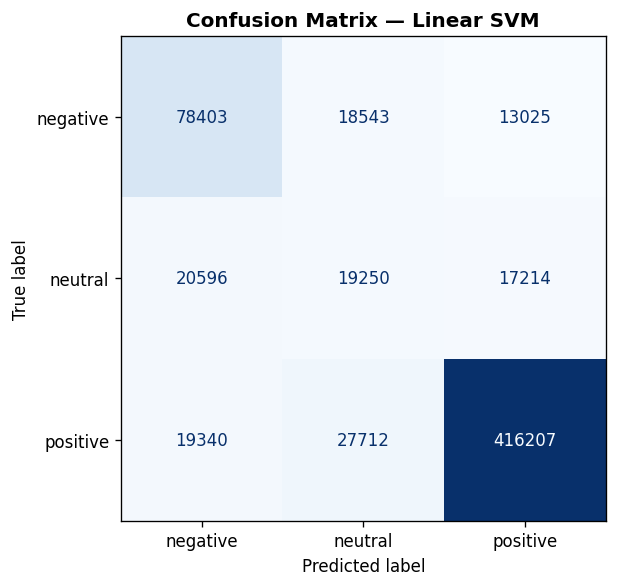

✅ Saved: sentiment_linear_svm.joblib


In [ ]:
# ============================================================
# CELL 6: Linear SVM (Support Vector Machine)
#
# Ý tưởng: Tìm HYPERPLANE tối ưu phân chia các class
#           Maximize margin (khoảng cách) giữa các class
#
# Tại sao Linear SVM thường tốt nhất với text?
# → Text data thường linearly separable ở high-dimensional space
# → Margin maximization giúp model generalize tốt
#
# LinearSVC vs SVC(kernel='linear'):
# → LinearSVC: dùng liblinear → nhanh hơn với data lớn
# → SVC      : dùng libsvm → chậm hơn nhưng flexible hơn
#
# Tham số:
# → C=1.0           : trade-off giữa margin rộng và lỗi ít
# → max_iter=2000   : cần nhiều vòng lặp hơn LR
# → class_weight='balanced'
# ============================================================

svm_model = LinearSVC(
    C            = 1.0,
    max_iter     = 2000,
    class_weight = 'balanced',
    random_state = 42
)

svm_result = train_and_evaluate(
    svm_model, 'Linear SVM',
    X_train, y_train, X_test, y_test
)

## Cell 7 — Model 4: Random Forest


🤖 Model: Random Forest
🔄 Training... (sẽ báo mỗi 30 giây)
   ⏱️  [Random Forest] Đang train: 00:30...
   ⏱️  [Random Forest] Đang train: 01:00...
   ⏱️  [Random Forest] Đang train: 01:30...
   ⏱️  [Random Forest] Đang train: 02:00...
   ⏱️  [Random Forest] Đang train: 02:30...
   ⏱️  [Random Forest] Đang train: 03:00...
   ⏱️  [Random Forest] Đang train: 03:30...
   ⏱️  [Random Forest] Đang train: 04:00...
   ⏱️  [Random Forest] Đang train: 04:30...
   ⏱️  [Random Forest] Đang train: 05:00...
   ⏱️  [Random Forest] Đang train: 05:30...
   ⏱️  [Random Forest] Đang train: 06:00...
   ⏱️  [Random Forest] Đang train: 06:30...
   ⏱️  [Random Forest] Đang train: 07:00...
   ⏱️  [Random Forest] Đang train: 07:30...
   ⏱️  [Random Forest] Đang train: 08:00...
   ⏱️  [Random Forest] Đang train: 08:30...
   ⏱️  [Random Forest] Đang train: 09:00...
   ⏱️  [Random Forest] Đang train: 09:30...
   ⏱️  [Random Forest] Đang train: 10:00...
   ⏱️  [Random Forest] Đang train: 10:30...
   ⏱️  [Random Fo

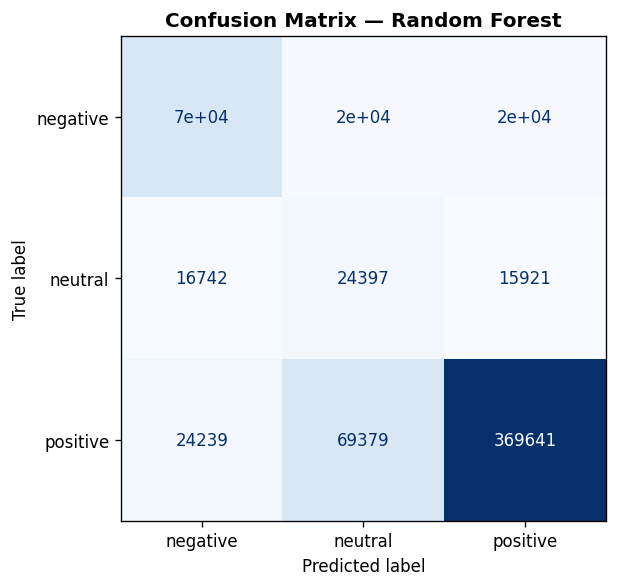

✅ Saved: sentiment_random_forest.joblib


In [6]:
# ============================================================
# CELL 7: Random Forest
#
# Ý tưởng: Ensemble của nhiều Decision Trees
#   → Mỗi tree được train trên subset ngẫu nhiên của data
#   → Kết quả cuối = vote majority của tất cả trees
#
# Ưu điểm:
# → Ít overfit hơn single Decision Tree
# → Không cần normalize features
# → Tự nhiên xử lý tốt imbalanced data
#
# Nhược điểm:
# → Chậm hơn Linear models với sparse matrix
# → Tốn RAM hơn
#
# ⚠️ Vì X_train sparse matrix rất lớn (2.4M × 262k)
# → Giảm n_estimators=100 và max_features='sqrt'
#   để tránh OOM và chạy trong thời gian hợp lý
#
# Tham số:
# → n_estimators=100  : số lượng trees
# → max_features='sqrt': mỗi split chỉ xem sqrt(n_features)
# → max_depth=20      : giới hạn độ sâu → tránh overfit
# → class_weight='balanced'
# → n_jobs=-1         : parallel training
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators = 500,
    max_features = 'sqrt',
    max_depth    = 20,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

rf_result = train_and_evaluate(
    rf_model, 'Random Forest',
    X_train, y_train, X_test, y_test
)

In [10]:
# ============================================================
# Tự động load lại model và tính lại metrics
# Không cần nhập tay
# ============================================================

import joblib
import time
from sklearn.metrics import f1_score

model_files = {
    'Logistic Regression' : 'sentiment_logistic_regression.joblib',
    'SGD Classifier'      : 'sentiment_sgd_classifier.joblib',
    'Linear SVM'          : 'sentiment_linear_svm.joblib',
    'Random Forest'       : 'sentiment_random_forest.joblib',
}

print('🔄 Load lại models và tính metrics...\n')

for model_name, fname in model_files.items():
    fpath = MODELS_DIR / fname

    # Kiểm tra file tồn tại không
    if not fpath.exists():
        print(f'❌ Không tìm thấy: {fname} → bỏ qua')
        continue

    # Load model
    print(f'📦 Loading {model_name}...')
    model = joblib.load(fpath)

    # Predict
    t0     = time.time()
    y_pred = model.predict(X_test)
    t1     = time.time()

    # Tính metrics
    f1_macro     = f1_score(y_test, y_pred, average='macro')
    f1_weighted  = f1_score(y_test, y_pred, average='weighted')
    f1_per_class = f1_score(y_test, y_pred, average=None)

    # Lưu vào all_results
    all_results[model_name] = {
        'model'         : model_name,
        'train_time_s'  : 0,
        'train_time_fmt': 'N/A',
        'f1_macro'      : round(f1_macro, 4),
        'f1_weighted'   : round(f1_weighted, 4),
        'f1_negative'   : round(f1_per_class[0], 4),
        'f1_neutral'    : round(f1_per_class[1], 4),
        'f1_positive'   : round(f1_per_class[2], 4),
    }

    print(f'   ✅ F1-Macro={f1_macro:.4f} | F1-Weighted={f1_weighted:.4f} | {t1-t0:.1f}s\n')

# Lưu lại JSON đầy đủ
with open(MODELS_DIR / 'sentiment_traditional_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

print('='*55)
print('✅ Đã load đủ tất cả model:')
for name, r in all_results.items():
    print(f'   {name:<22}: F1-Macro={r["f1_macro"]} | F1-Weighted={r["f1_weighted"]}')

🔄 Load lại models và tính metrics...

📦 Loading Logistic Regression...
   ✅ F1-Macro=0.5472 | F1-Weighted=0.7008 | 0.4s

📦 Loading SGD Classifier...
   ✅ F1-Macro=0.6387 | F1-Weighted=0.8201 | 0.2s

📦 Loading Linear SVM...
   ✅ F1-Macro=0.6387 | F1-Weighted=0.8208 | 0.1s

📦 Loading Random Forest...
   ✅ F1-Macro=0.5908 | F1-Weighted=0.7622 | 55.4s

✅ Đã load đủ tất cả model:
   Random Forest         : F1-Macro=0.5908 | F1-Weighted=0.7622
   Logistic Regression   : F1-Macro=0.5472 | F1-Weighted=0.7008
   SGD Classifier        : F1-Macro=0.6387 | F1-Weighted=0.8201
   Linear SVM            : F1-Macro=0.6387 | F1-Weighted=0.8208


## Cell 8 — So sánh tất cả model

📊 BẢNG SO SÁNH KẾT QUẢ — TRADITIONAL ML
              model  f1_macro  f1_weighted  f1_negative  f1_neutral  f1_positive  train_time_s
         Linear SVM    0.6387       0.8208       0.6868      0.3141       0.9150             0
     SGD Classifier    0.6387       0.8201       0.6989      0.3047       0.9124             0
      Random Forest    0.5908       0.7622       0.6354      0.2860       0.8510             0
Logistic Regression    0.5472       0.7008       0.5673      0.2913       0.7830             0


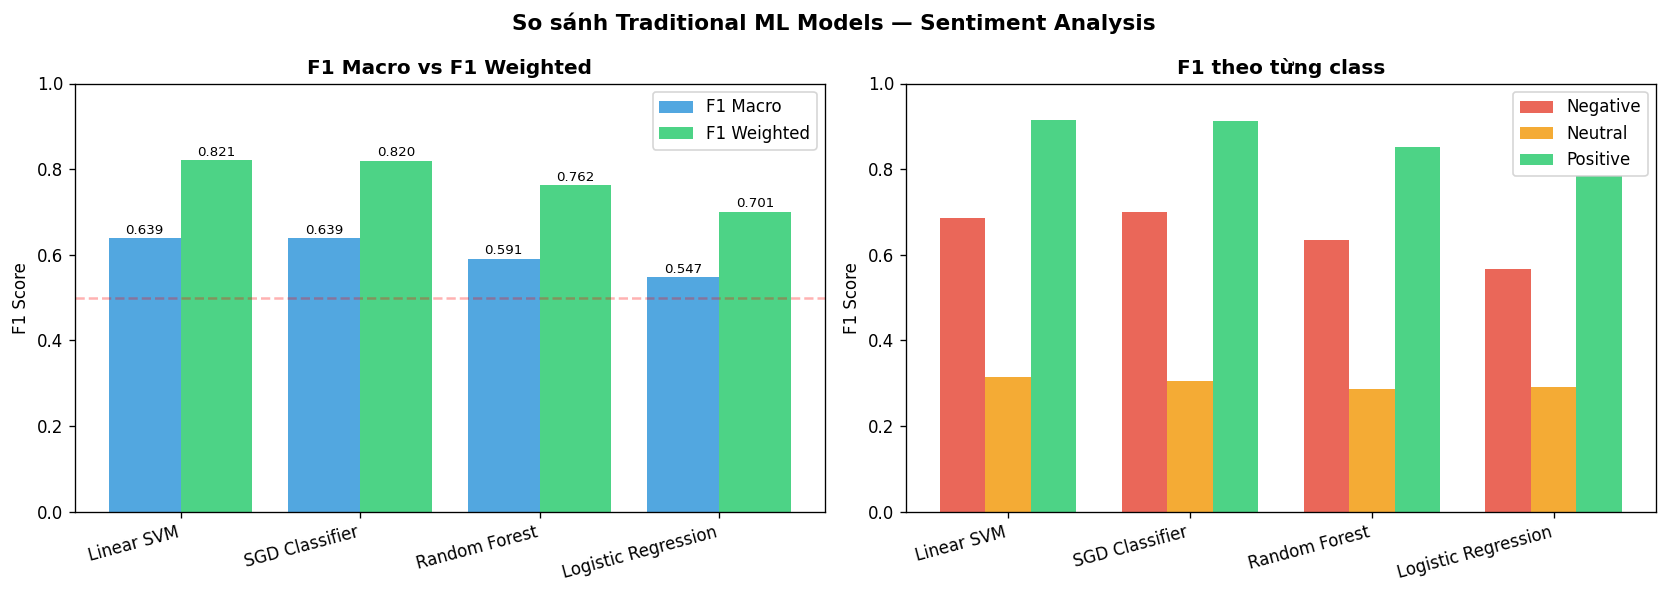


🏆 Model tốt nhất: Linear SVM
   F1 Macro   : 0.6387
   F1 Weighted: 0.8208

✅ Saved: sentiment_traditional_results.json


In [11]:
# ============================================================
# CELL 8: So sánh kết quả tất cả 4 model
#
# Vẽ 2 biểu đồ:
# 1. Bar chart so sánh F1-macro và F1-weighted
# 2. Grouped bar chart F1 từng class (negative/neutral/positive)
#
# Tại sao cần xem F1 từng class?
# → F1-macro cao không có nghĩa model tốt đều ở mọi class
# → Model có thể giỏi positive nhưng kém neutral
# → Cần biết model yếu ở class nào để cải thiện
# ============================================================

import pandas as pd

# Tạo DataFrame kết quả
df_results = pd.DataFrame(list(all_results.values()))
df_results = df_results.sort_values('f1_macro', ascending=False)

print('='*65)
print('📊 BẢNG SO SÁNH KẾT QUẢ — TRADITIONAL ML')
print('='*65)
print(df_results[['model','f1_macro','f1_weighted',
                   'f1_negative','f1_neutral','f1_positive',
                   'train_time_s']].to_string(index=False))

# ── Biểu đồ 1: F1-macro và F1-weighted ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So sánh Traditional ML Models — Sentiment Analysis',
              fontsize=13, fontweight='bold')

models = df_results['model'].tolist()
x      = range(len(models))

# F1 scores
axes[0].bar([i - 0.2 for i in x], df_results['f1_macro'],
             width=0.4, label='F1 Macro', color='#3498db', alpha=0.85)
axes[0].bar([i + 0.2 for i in x], df_results['f1_weighted'],
             width=0.4, label='F1 Weighted', color='#2ecc71', alpha=0.85)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(models, rotation=15, ha='right')
axes[0].set_ylabel('F1 Score')
axes[0].set_ylim(0, 1.0)
axes[0].set_title('F1 Macro vs F1 Weighted', fontweight='bold')
axes[0].legend()
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.3, label='0.5 threshold')
for i, (macro, weighted) in enumerate(
    zip(df_results['f1_macro'], df_results['f1_weighted'])
):
    axes[0].text(i-0.2, macro+0.01, f'{macro:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, weighted+0.01, f'{weighted:.3f}', ha='center', fontsize=8)

# F1 theo từng class
width = 0.25
axes[1].bar([i - width for i in x], df_results['f1_negative'],
             width=width, label='Negative', color='#e74c3c', alpha=0.85)
axes[1].bar([i for i in x], df_results['f1_neutral'],
             width=width, label='Neutral', color='#f39c12', alpha=0.85)
axes[1].bar([i + width for i in x], df_results['f1_positive'],
             width=width, label='Positive', color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(models, rotation=15, ha='right')
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 1.0)
axes[1].set_title('F1 theo từng class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_traditional_ml_comparison.png',
             dpi=130, bbox_inches='tight')
plt.show()

# Model tốt nhất
best = df_results.iloc[0]
print(f'\n🏆 Model tốt nhất: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')

# Lưu kết quả ra JSON
with open(MODELS_DIR / 'sentiment_traditional_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)
print(f'\n✅ Saved: sentiment_traditional_results.json')

## Cell 9 — Phân tích lỗi của model tốt nhất

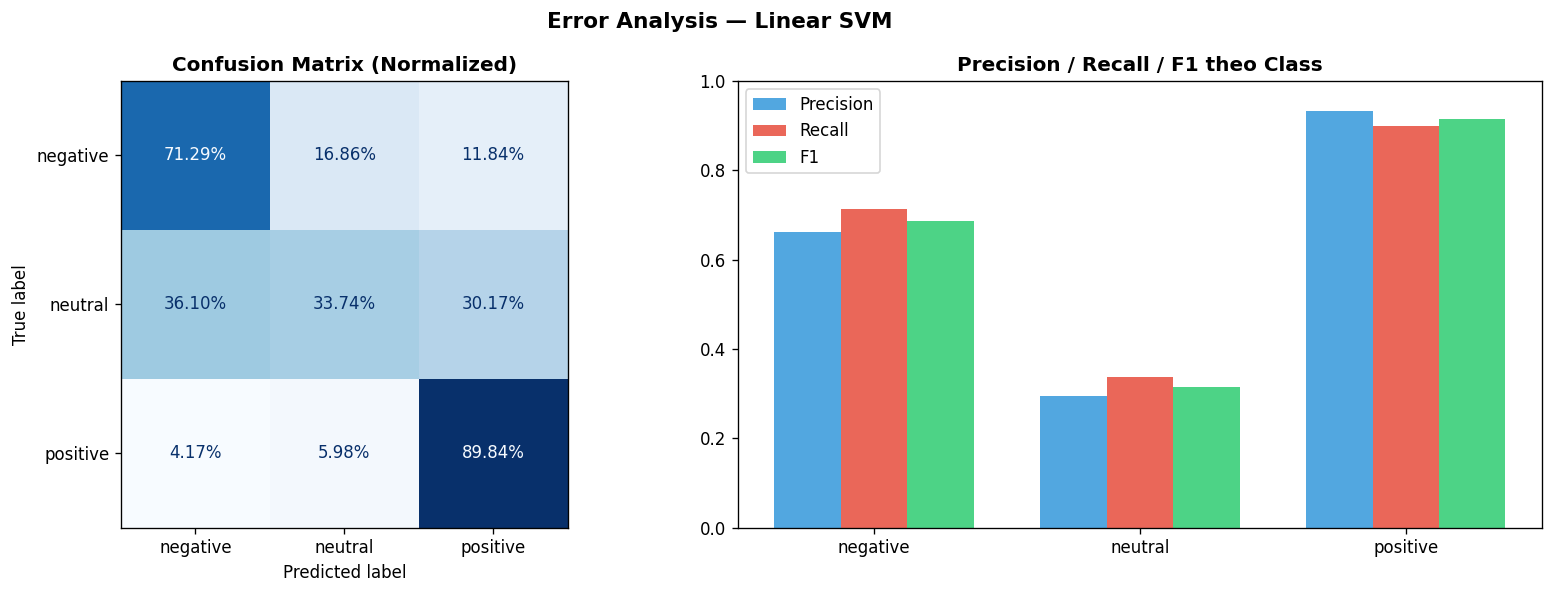


📊 Nhận xét Error Analysis:
   negative  : Precision=0.663 | Recall=0.713 | F1=0.687
   neutral   : Precision=0.294 | Recall=0.337 | F1=0.314
   positive  : Precision=0.932 | Recall=0.898 | F1=0.915

⚠️  Class kém nhất: neutral (F1=0.314)
   → Deep Learning (BERT) sẽ cải thiện class này


In [12]:
# ============================================================
# CELL 9: Phân tích lỗi (Error Analysis)
#
# Mục tiêu: Hiểu model đang nhầm ở đâu
#
# Phân tích:
# 1. Confusion matrix normalized → xem % nhầm
# 2. Per-class performance → class nào model kém nhất
#
# Tại sao cần Error Analysis?
# → Biết điểm yếu để cải thiện
# → Giải thích kết quả trong báo cáo
# → Quyết định có cần thêm data cho class yếu không
# ============================================================

# Load model tốt nhất
best_model_name = df_results.iloc[0]['model']
best_model_path = MODELS_DIR / f'sentiment_{best_model_name.replace(" ","_").lower()}.joblib'
best_model      = joblib.load(best_model_path)

y_pred_best = best_model.predict(X_test)

# Confusion matrix normalized (tỷ lệ %)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Error Analysis — {best_model_name}',
              fontsize=13, fontweight='bold')

# Confusion matrix normalized
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=LABEL_NAMES
)
disp.plot(ax=axes[0], cmap='Blues', colorbar=False,
           values_format='.2%')
axes[0].set_title('Confusion Matrix (Normalized)', fontweight='bold')

# Per-class F1, Precision, Recall
from sklearn.metrics import precision_recall_fscore_support
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_best, average=None
)

x    = range(len(LABEL_NAMES))
axes[1].bar([i-0.25 for i in x], precision, width=0.25,
             label='Precision', color='#3498db', alpha=0.85)
axes[1].bar([i for i in x],      recall,    width=0.25,
             label='Recall',    color='#e74c3c', alpha=0.85)
axes[1].bar([i+0.25 for i in x], f1,       width=0.25,
             label='F1',        color='#2ecc71', alpha=0.85)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(LABEL_NAMES)
axes[1].set_ylim(0, 1.0)
axes[1].set_title('Precision / Recall / F1 theo Class', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'step5_error_analysis.png',
             dpi=130, bbox_inches='tight')
plt.show()

print('\n📊 Nhận xét Error Analysis:')
for i, (name, p, r, f) in enumerate(
    zip(LABEL_NAMES, precision, recall, f1)
):
    print(f'   {name:10}: Precision={p:.3f} | Recall={r:.3f} | F1={f:.3f}')

# Class nào kém nhất?
worst_class = LABEL_NAMES[f1.argmin()]
print(f'\n⚠️  Class kém nhất: {worst_class} (F1={f1.min():.3f})')
print(f'   → Deep Learning (BERT) sẽ cải thiện class này')

## Cell 10 — Tổng kết Phần A

In [13]:
# ============================================================
# CELL 10: Tổng kết Phần A và chuẩn bị cho Phần B
# ============================================================

print('='*65)
print('🎉 TỔNG KẾT PHẦN A — TRADITIONAL ML')
print('='*65)

print('\n📊 Bảng so sánh cuối:')
print(f'{"Model":<22} {"F1-Macro":>10} {"F1-Weighted":>12} {"Time(s)":>10}')
print('-'*58)
for _, row in df_results.iterrows():
    print(f'{row["model"]:<22} {row["f1_macro"]:>10.4f} '
          f'{row["f1_weighted"]:>12.4f} {row["train_time_s"]:>10.1f}')

best = df_results.iloc[0]
print(f'\n🏆 Best model: {best["model"]}')
print(f'   F1 Macro   : {best["f1_macro"]}')
print(f'   F1 Weighted: {best["f1_weighted"]}')

print('\n📁 Files đã lưu:')
for f in sorted(MODELS_DIR.glob('sentiment_*.joblib')):
    sz = f.stat().st_size / (1024**2)
    print(f'   {f.name:<45} {sz:.1f} MB')
print(f'   sentiment_traditional_results.json')

print('\n📌 Nhận xét chung:')
print('   → Linear models (LR, SVM, SGD) thường tốt hơn RF với text')
print('   → class_weight=balanced giúp cải thiện F1 neutral & negative')
print('   → neutral là class khó nhất vì nằm giữa positive và negative')

print('\n🚀 Tiếp theo: Phần B — Deep Learning (TextCNN, BiLSTM, DistilBERT)')
print('   → Cần raw text từ review_clean.parquet')
print('   → Cần GPU T4 để train nhanh hơn')

🎉 TỔNG KẾT PHẦN A — TRADITIONAL ML

📊 Bảng so sánh cuối:
Model                    F1-Macro  F1-Weighted    Time(s)
----------------------------------------------------------
Linear SVM                 0.6387       0.8208        0.0
SGD Classifier             0.6387       0.8201        0.0
Random Forest              0.5908       0.7622        0.0
Logistic Regression        0.5472       0.7008        0.0

🏆 Best model: Linear SVM
   F1 Macro   : 0.6387
   F1 Weighted: 0.8208

📁 Files đã lưu:
   sentiment_linear_svm.joblib                   6.0 MB
   sentiment_logistic_regression.joblib          6.0 MB
   sentiment_random_forest.joblib                76.5 MB
   sentiment_sgd_classifier.joblib               6.0 MB
   sentiment_traditional_results.json

📌 Nhận xét chung:
   → Linear models (LR, SVM, SGD) thường tốt hơn RF với text
   → class_weight=balanced giúp cải thiện F1 neutral & negative
   → neutral là class khó nhất vì nằm giữa positive và negative

🚀 Tiếp theo: Phần B — Deep Learni